# Introduction

In Lesson 2 we began our discussion of how the base in a convnet performs feature extraction. 
We learned about how the first two operations in this process occur in a `Conv2D` layer with `relu` activation.

In this lesson, we'll look at the third (and final) operation in this sequence: **condense with maximum pooling**, 
which in Keras is done by a `MaxPool2D` layer.

---

# Condense with Maximum Pooling

The **condensing step** reduces the size of the feature map while keeping the most important information.

Adding the condensing step to the model we had before gives us this:


In [1]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=64, kernel_size=3), # activation is None
    layers.MaxPool2D(pool_size=2),
    # More layers follow
])

## MaxPool2D vs Conv2D

A `MaxPool2D` layer is much like a `Conv2D` layer, except that:

- It uses a simple **maximum function** instead of a kernel
- The `pool_size` parameter is analogous to `kernel_size`
- It has **no trainable weights** — it just picks the max value, nothing to learn

| | Conv2D | MaxPool2D |
|---|---|---|
| Operation | Weighted sum (kernel) | Maximum value |
| Trainable weights | ✅ Yes (the kernel values) | ❌ No |
| Parameter | `kernel_size` | `pool_size` |
| Purpose | Detect features | Condense features |

---

## Why Do We Need Condensing?

After applying ReLU, the feature map ends up with a lot of **"dead space"** — large areas 
containing only `0`s. Carrying these zero activations through the entire network would:

- Increase the size of the model
- Add no useful information

Instead, we **condense** the feature map to retain only the most useful part — the feature itself.

> 💡 **Max pooling takes a patch of activations and replaces them with the maximum activation 
> in that patch.**

When applied after ReLU, it has the effect of **"intensifying" features** — it increases the 
proportion of active pixels to zero pixels.



---

## Example — Apply Maximum Pooling

Let's add the **condense** step to the feature extraction we did in Lesson 2.

The cells below pick up from where we left off — after convolution and ReLU — and apply 
`MaxPool2D` to condense the feature map.


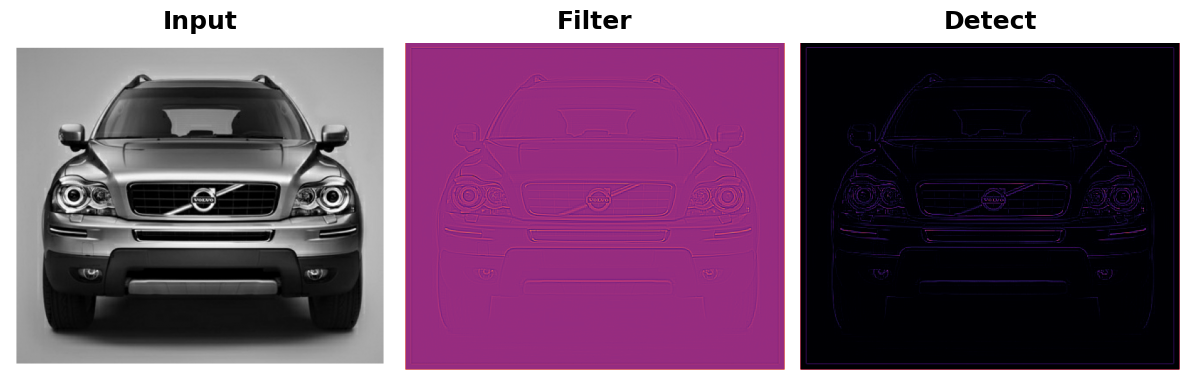

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import warnings

plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore")

# Read image
image_path = '../images/car.png'
image = tf.io.read_file(image_path)
image = tf.io.decode_png(image, channels=1)  # ← fixed: png not jpeg, channels=1 forces grayscale

# Define kernel
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
], dtype=tf.float32)

# Reformat for batch compatibility
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])

# Filter step
image_filter = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=1,
    padding='SAME'
)

# Detect step
image_detect = tf.nn.relu(image_filter)

# Show what we have so far
plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.imshow(tf.squeeze(image), cmap='gray')
plt.axis('off')
plt.title('Input')
plt.subplot(132)
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.title('Filter')
plt.subplot(133)
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.title('Detect')
plt.show()


We'll use another one of the functions in tf.nn to apply the pooling step, tf.nn.pool. This is a Python function that does the same thing as the MaxPool2D layer you use when model building, but, being a simple function, is easier to use directly.

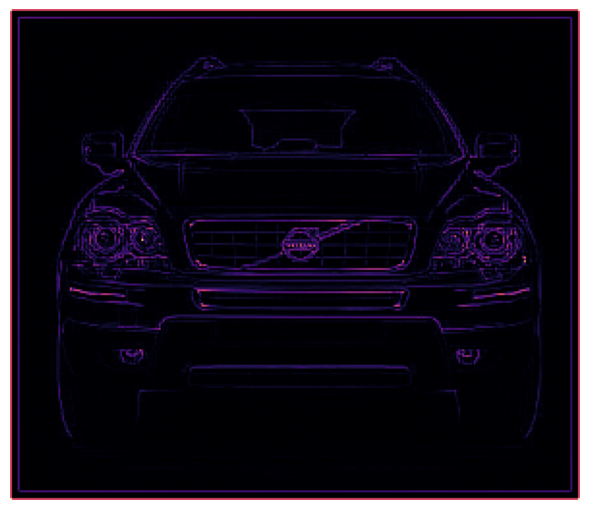

In [7]:
import tensorflow as tf

image_condense = tf.nn.pool(
    input=image_detect, # image in the Detect step above
    window_shape=(2, 2),
    pooling_type='MAX',
    # we'll see what these do in the next lesson!
    strides=(2, 2),
    padding='SAME',
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_condense))
plt.axis('off')
plt.show();

---

## Translation Invariance

The zero-pixels removed by MaxPool2D aren't completely useless — they carry **positional information**. 
When MaxPool2D removes them, it removes some of that positional information, giving the network a 
property called **translation invariance**.

> 💡 **Translation invariance** means the network tends not to distinguish features by their 
> *location* in the image. ("Translation" = moving something without rotating or resizing it.)

---

### What Happens with Repeated Pooling?

After applying MaxPool2D repeatedly, nearby features **merge and become indistinguishable**:




The two dots started separate but pooling destroyed enough positional info 
that the network can no longer tell them apart.

---

### But Only Over Small Distances

| Feature distance | Effect of pooling |
|---|---|
| **Close together** | May merge — positional info lost |
| **Far apart** | Stay distinct — some info lost but not all |

---

### Why Is This Actually Useful?

Because of differences in **perspective or framing**, the same feature might appear in 
different parts of an image. We still want the classifier to recognize it as the same feature.

**Benefits of translation invariance:**

- ✅ No need to teach the network to ignore small position differences
- ✅ Works with **much less training data**
- ✅ Big efficiency advantage over networks with only dense layers

> 🔑 This invariance is **built into the network for free** through pooling — 
> you'll see another way to get it for free in Lesson 6 with **Data Augmentation!**


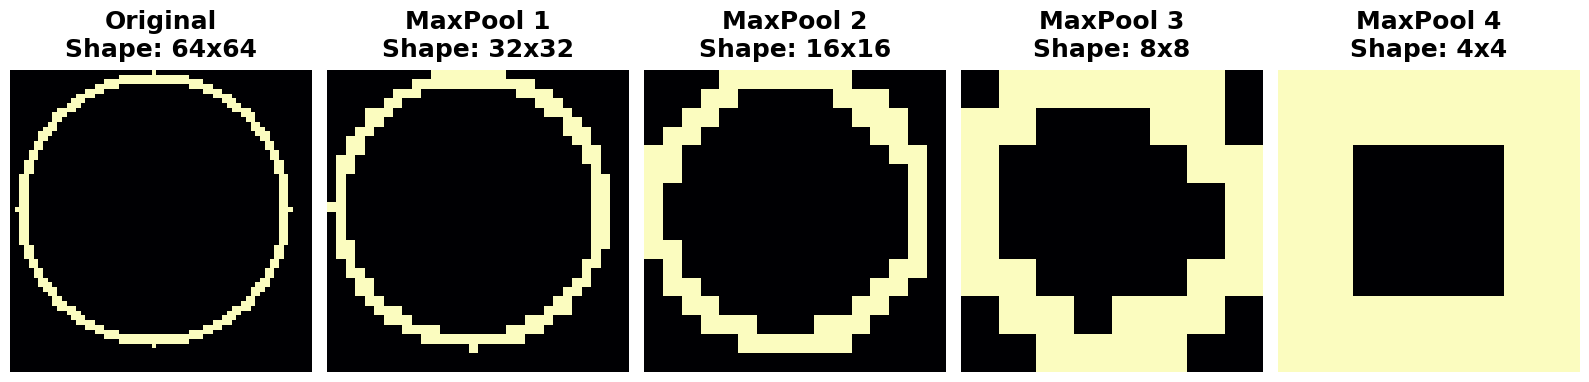

In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

REPEATS = 4
SIZE = [64, 64]

# ── Helper: create a circle image ──────────────────────────────────────────────
def make_circle(size, r_shrink=4, val=1, thickness=1):
    """Creates a circle OUTLINE (ring), not a filled disk."""
    h, w = size
    cx, cy = w // 2, h // 2
    radius = min(cx, cy) - r_shrink

    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((x - cx)**2 + (y - cy)**2)  # distance of each pixel from center

    # Only pixels ON the edge of the circle (within 'thickness' of the radius)
    mask = (dist >= radius - thickness) & (dist <= radius + thickness)

    img = np.zeros((h, w), dtype=np.float32)
    img[mask] = val
    return tf.constant(img)


# ── Helper: randomly shift (jitter) the image ──────────────────────────────────
def random_jitter(image, jitter=3, fill_method='replicate'):
    """Randomly shifts image by up to jitter pixels in x and y."""
    img = image.numpy()
    if len(img.shape) == 3:
        img = img[:, :, 0]             # squeeze channel dim for processing

    dx = np.random.randint(-jitter, jitter + 1)   # random x shift
    dy = np.random.randint(-jitter, jitter + 1)   # random y shift

    # Pad with edge values (replicate), then crop back to original size
    padded = np.pad(img, jitter, mode='edge')
    shifted = padded[
        jitter + dy : jitter + dy + img.shape[0],
        jitter + dx : jitter + dx + img.shape[1]
    ]
    return tf.constant(shifted[..., np.newaxis], dtype=tf.float32)  # restore channel dim

# ── Main ───────────────────────────────────────────────────────────────────────
# Create a randomly shifted circle
image = make_circle(SIZE, r_shrink=4, val=1)
image = tf.expand_dims(image, axis=-1)          # add channel dim → [64, 64, 1]
image = random_jitter(image, jitter=3, fill_method='replicate')
image = tf.squeeze(image)                       # back to [64, 64]

plt.figure(figsize=(16, 4))
plt.subplot(1, REPEATS + 1, 1)
plt.imshow(image, vmin=0, vmax=1)
plt.title("Original\nShape: {}x{}".format(image.shape[0], image.shape[1]))
plt.axis('off')

# Condense with maximum pooling several times
for i in range(REPEATS):
    plt.subplot(1, REPEATS + 1, i + 2)
    image = tf.reshape(image, [1, *image.shape, 1])   # add batch + channel dims
    image = tf.nn.pool(
        image,
        window_shape=(2, 2),     # look at 2×2 patches
        strides=(2, 2),          # move 2 pixels at a time → halves size each step
        padding='SAME',
        pooling_type='MAX'       # keep the maximum value in each patch
    )
    image = tf.squeeze(image)    # remove batch + channel dims for display
    plt.imshow(image, vmin=0, vmax=1)
    plt.title("MaxPool {}\nShape: {}x{}".format(i + 1, image.shape[0], image.shape[1]))
    plt.axis('off')

plt.tight_layout()
plt.show()


---

## Explore Invariance

**Question:** If you shift the circle in a different direction, what effect does that 
have on the final pooled image?

**Answer:** Almost none — and that's exactly the point.

No matter which direction you shift the circle (left, right, up, down, diagonal), 
after enough rounds of MaxPooling the result looks nearly identical. 
The pooling operation **destroys the small positional difference**, making the network 
*invariant* to that shift.

> 🔑 This is **translation invariance** in action:
> - Small shift → pooled result looks the same ✅  
> - Large shift → pooled result stays different ✅ (invariance only works over small distances)

Run the cell below multiple times to see different random shifts — notice how the 
final MaxPool stages always converge to the same result regardless of direction.


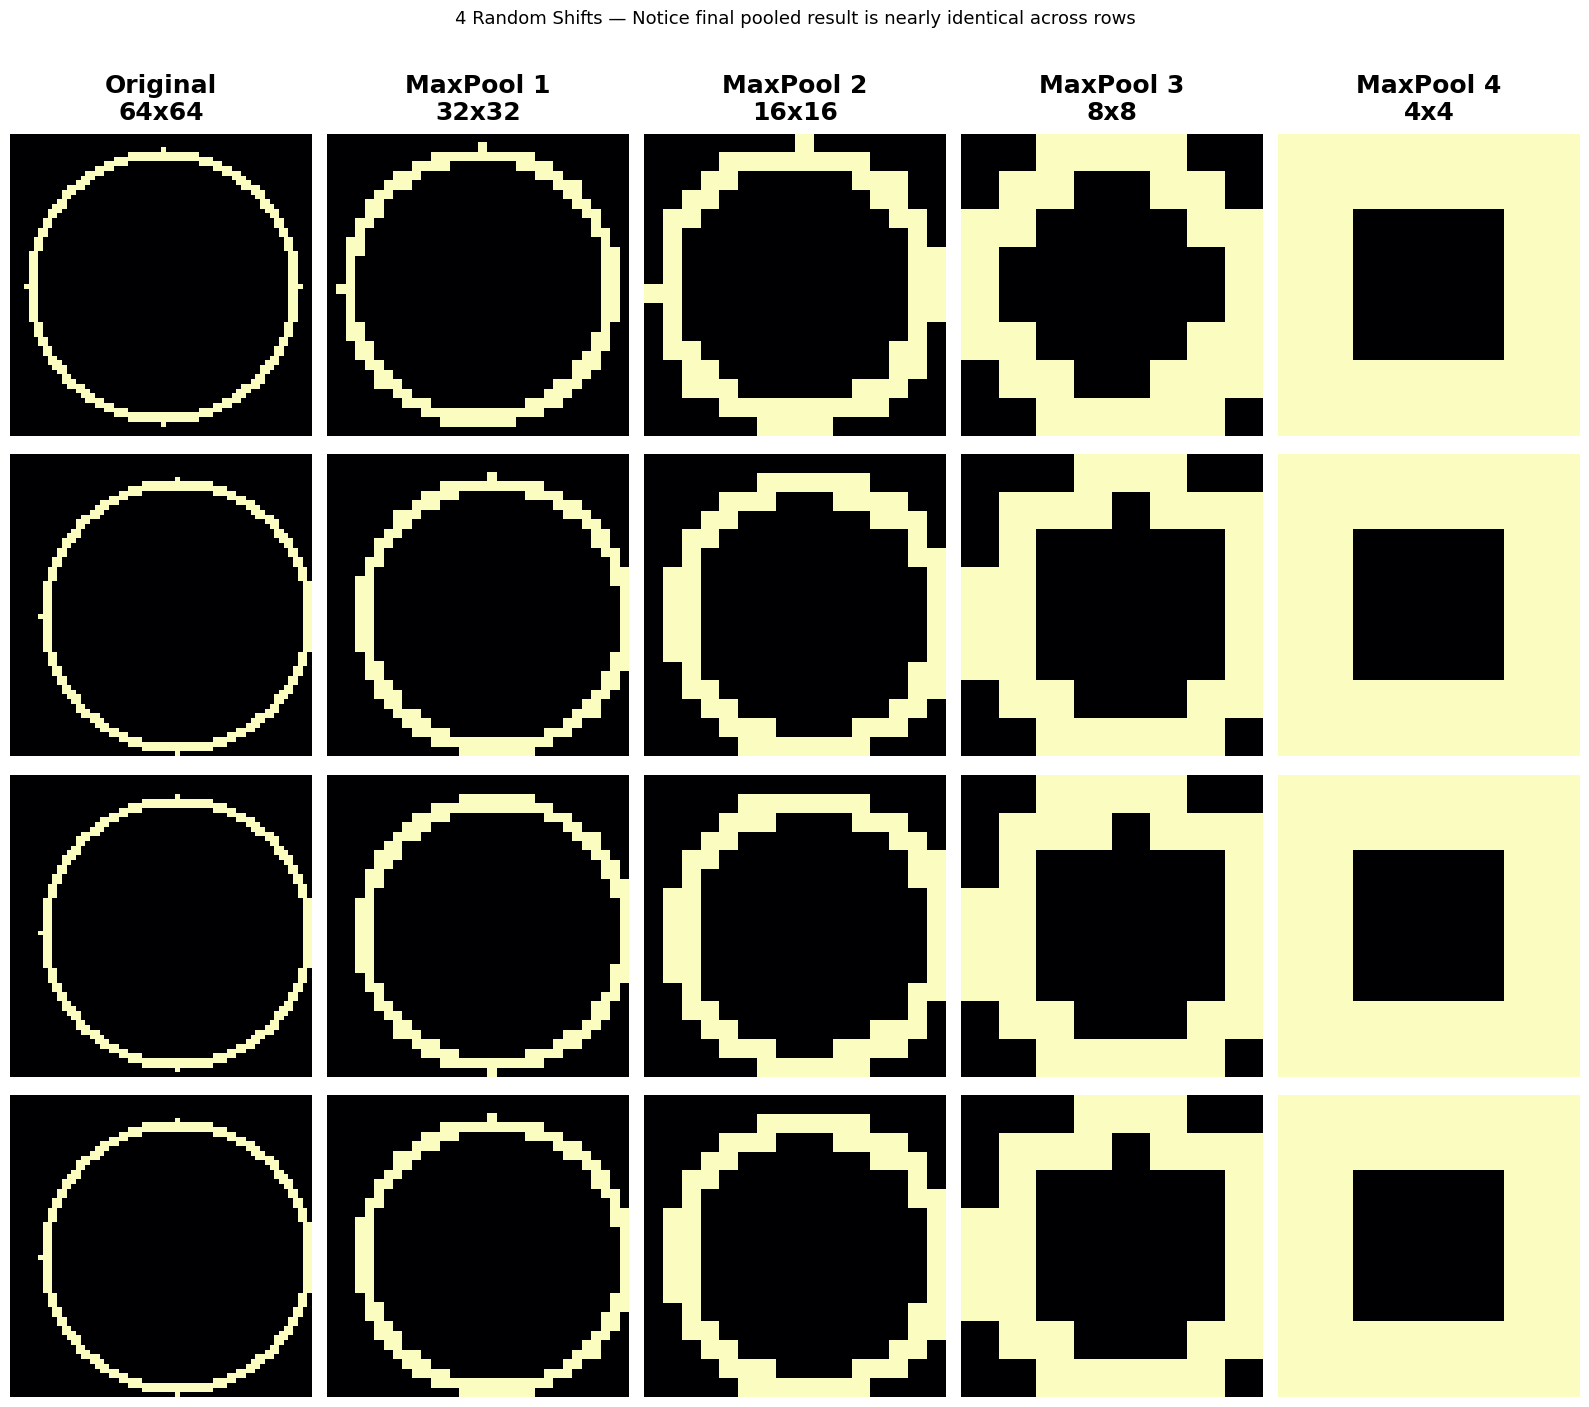

In [15]:
REPEATS = 4
ROWS = 4
SIZE = [64, 64]

np.random.seed(None)

fig, axes = plt.subplots(ROWS, REPEATS + 1, figsize=(16, 14))

for row in range(ROWS):
    # Create a new randomly shifted circle for each row
    image = make_circle(SIZE, r_shrink=4, val=1)
    image = tf.expand_dims(image, axis=-1)
    image = random_jitter(image, jitter=3, fill_method='replicate')
    image = tf.squeeze(image)

    # Original
    axes[row, 0].imshow(image, vmin=0, vmax=1)
    axes[row, 0].set_title("Original\n{}x{}".format(image.shape[0], image.shape[1]) if row == 0 else "")
    axes[row, 0].axis('off')

    # Apply pooling REPEATS times
    for i in range(REPEATS):
        image = tf.reshape(image, [1, *image.shape, 1])
        image = tf.nn.pool(
            image,
            window_shape=(2, 2),
            strides=(2, 2),
            padding='SAME',
            pooling_type='MAX'
        )
        image = tf.squeeze(image)
        axes[row, i + 1].imshow(image, vmin=0, vmax=1)
        axes[row, i + 1].set_title("MaxPool {}\n{}x{}".format(i + 1, image.shape[0], image.shape[1]) if row == 0 else "")
        axes[row, i + 1].axis('off')

plt.suptitle("4 Random Shifts — Notice final pooled result is nearly identical across rows", 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---

## Global Average Pooling

Within the convolutional **base**, maximum pooling is the standard. But in the **head** 
of the network, there's a different kind of pooling still widely used: **Global Average Pooling**.

```python
model = keras.Sequential([
    pretrained_base,
    layers.GlobalAvgPool2D(),          # replaces Flatten + some Dense layers
    layers.Dense(1, activation='sigmoid'),
])


## What Does GlobalAvgPool2D Do?

1. Takes each feature map
2. Computes its **single average value**
3. Lines all those averages up → a **flat 1D vector**



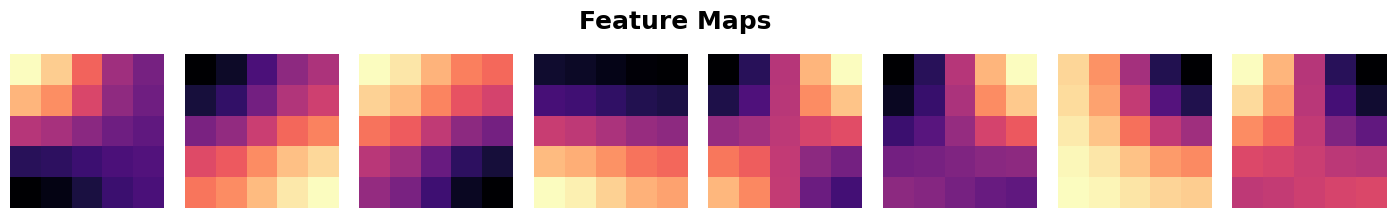

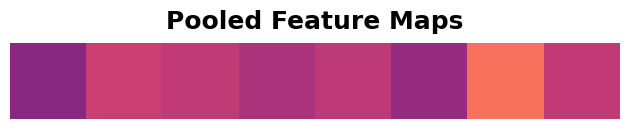

In [17]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import zoom

# ── Helper: generate a smooth random feature map ───────────────────────────────
def random_map(size, scale=0.1, decay_power=4):
    """
    Generates a smooth random feature map.
    - scale:       controls smoothness (lower = smoother blobs)
    - decay_power: controls interpolation order (higher = smoother)
    """
    h, w = size
    # Generate a tiny random grid and zoom up → creates smooth blobs
    small_h = max(2, int(h * scale) + 2)
    small_w = max(2, int(w * scale) + 2)
    noise = np.random.randn(small_h, small_w)

    # Zoom to target size using spline interpolation (order controlled by decay_power)
    zoomed = zoom(noise, (h / small_h, w / small_w), order=min(decay_power - 1, 5))

    # Normalize to [0, 1]
    zoomed = (zoomed - zoomed.min()) / (zoomed.max() - zoomed.min() + 1e-8)
    return tf.constant(zoomed.astype(np.float32))

# ── Generate 8 random feature maps ────────────────────────────────────────────
feature_maps = [random_map([5, 5], scale=0.1, decay_power=4) for _ in range(8)]

gs = gridspec.GridSpec(1, 8, wspace=0.01, hspace=0.01)
plt.figure(figsize=(18, 2))
for i, feature_map in enumerate(feature_maps):
    plt.subplot(gs[i])
    plt.imshow(feature_map, vmin=0, vmax=1)
    plt.axis('off')
plt.suptitle('Feature Maps', size=18, weight='bold', y=1.1)
plt.show()

# ── Reformat for TensorFlow ────────────────────────────────────────────────────
feature_maps_tf = [
    tf.reshape(feature_map, [1, *feature_map.shape, 1])
    for feature_map in feature_maps
]

# ── Apply Global Average Pooling ───────────────────────────────────────────────
# Each 5×5 feature map → 1 single average value
global_avg_pool = tf.keras.layers.GlobalAvgPool2D()
pooled_maps = [global_avg_pool(feature_map) for feature_map in feature_maps_tf]

# Stack into a [1, 8] array and display as a 1-pixel-tall image
img = np.array(pooled_maps)[:, :, 0].T   # shape → [1, 8]

plt.imshow(img, vmin=0, vmax=1)
plt.axis('off')
plt.title('Pooled Feature Maps')
plt.show()


---

## From Feature Maps to Classifications

Since each feature map was reduced to a single value, `GlobalAvgPool2D` reduced the number 
of parameters by a factor of **25** (5×5 = 25 values → 1 value). A substantial saving!

**But does the head still have enough information to classify correctly?**

Let's pass images from a Car vs Truck dataset through **VGG16** and examine what the 
pooled features look like — and whether they're still separable by class.


In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image_dataset_from_directory

# ── Load VGG16 pretrained base ─────────────────────────────────────────────────
pretrained_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=[128, 128, 3]
)
pretrained_base.trainable = False

model = keras.Sequential([
    pretrained_base,
    layers.GlobalAvgPool2D(),
])

# ── Load Car vs Truck dataset ──────────────────────────────────────────────────
ds = image_dataset_from_directory(
    '../dataset/car_truck',  # ← Car/ and Truck/ subfolders are here
    labels='inferred',       # label = subfolder name (Car or Truck)
    label_mode='binary',     # Car=0, Truck=1 (alphabetical)
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=1,
    shuffle=True,
)

ds_iter = iter(ds)


Found 180 files belonging to 2 classes.


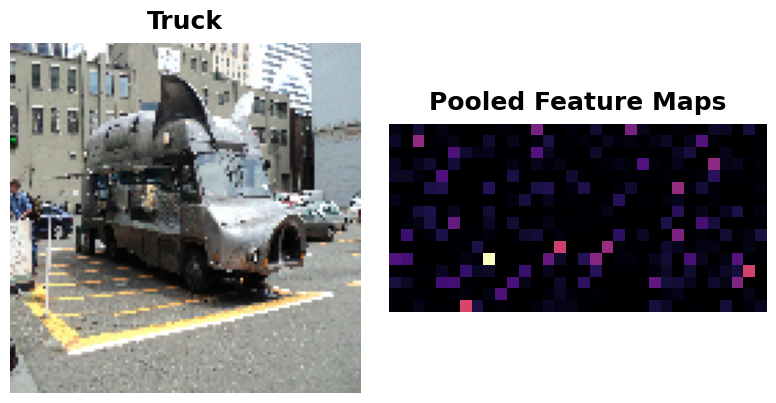

In [19]:
car = next(ds_iter)

car_tf = tf.image.resize(car[0], size=[128, 128])
car_features = model(car_tf)
car_features = tf.reshape(car_features, shape=(16, 32))
label = int(tf.squeeze(car[1]).numpy())

plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(tf.squeeze(car[0]))
plt.axis('off')
plt.title(["Car", "Truck"][label])
plt.subplot(122)
plt.imshow(car_features)
plt.title('Pooled Feature Maps')
plt.axis('off')
plt.show();

---

## Understand the Pooled Features

Run the cell below to pass one car and one truck image through the model and 
visualize their pooled feature vectors.

**Think about:**
- Are the pooled features for cars and trucks different enough to tell them apart?
- What do the pooled values represent?
- How could this help classification?


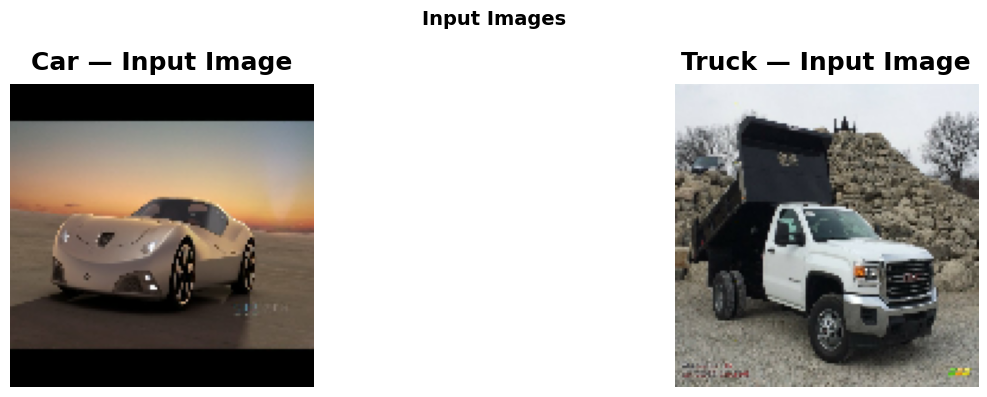

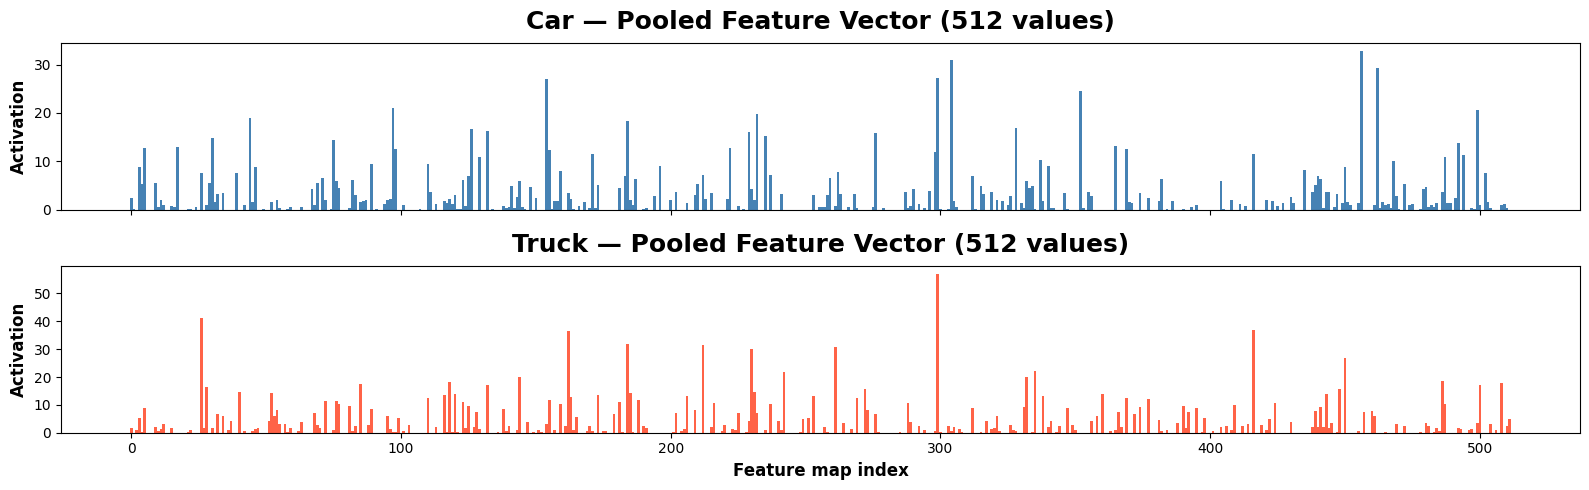

In [20]:
# Get one car image and one truck image from the dataset
car_image, car_label = next(ds_iter)
while car_label[0] != 0:                     # 0 = Car (alphabetical: Car < Truck)
    car_image, car_label = next(ds_iter)

truck_image, truck_label = next(ds_iter)
while truck_label[0] != 1:                   # 1 = Truck
    truck_image, truck_label = next(ds_iter)

# Pass both through VGG16 + GlobalAvgPool2D
car_features   = model.predict(car_image,   verbose=0)    # shape: [1, 512]
truck_features = model.predict(truck_image, verbose=0)    # shape: [1, 512]

# Plot the pooled feature vectors side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].imshow(car_image[0].numpy().astype('uint8'))
axes[0].set_title("Car — Input Image")
axes[0].axis('off')

axes[1].imshow(truck_image[0].numpy().astype('uint8'))
axes[1].set_title("Truck — Input Image")
axes[1].axis('off')

plt.suptitle("Input Images", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# Plot pooled feature vectors as bar charts
fig, axes = plt.subplots(2, 1, figsize=(16, 5), sharex=True)

axes[0].bar(range(len(car_features[0])), car_features[0], color='steelblue', width=1.0)
axes[0].set_ylabel("Activation")
axes[0].set_title("Car — Pooled Feature Vector (512 values)")

axes[1].bar(range(len(truck_features[0])), truck_features[0], color='tomato', width=1.0)
axes[1].set_ylabel("Activation")
axes[1].set_title("Truck — Pooled Feature Vector (512 values)")

plt.xlabel("Feature map index")
plt.tight_layout()
plt.show()


## Answer

Yes — the pooled feature vectors for cars and trucks are different enough to classify!

Each value in the vector answers: **"Was this feature present in the image?"**

| Value | Meaning |
|-------|---------|
| High (bright bar) | That feature map fired strongly — the pattern WAS detected |
| Low / zero | That feature map was mostly inactive — the pattern was NOT detected |

Because cars and trucks activate **different sets of features** (wheels, body shape, 
cab height, etc.), their pooled vectors look different — and a Dense layer can easily 
learn to separate them.

> 🔑 **Key takeaway:** `GlobalAvgPool2D` is a powerful and efficient alternative to 
> `Flatten`. It drastically reduces parameters while still preserving **which features 
> were present** — which is all a classifier really needs.
>
> If you're building a convolutional classifier, it's always worth trying!
